In [196]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import xobjects as xo
import xtrack as xt
import xpart as xp
import xcoll as xc

# Make a context and get a buffer
context = xo.ContextCpu()         # For CPU
# context = xo.ContextCupy()      # For CUDA GPUs
# context = xo.ContextPyopencl()  # For OpenCL GPUs

Let's build a Crystal that is horizontally deplaced as in the ZS drop in case:
the deplacement is given by the parameter jaw (?)

In [269]:
coll = xc.EverestCrystal(length=0.002,
                         material = xc.materials.SiliconCrystal,
                         bending_angle = 500e-6 ,
                         width = 0.02,
                         height = 0.05,
                         side = 'left', 
                         miscut = 0.,
                         lattice = 'strip',
                         jaw = 0.068,
                         #angle = 1650.e-6, # doesn't change anything
                         tilt = -1500.e-6,
                         
                         _context=context)

print(coll)

EverestCrystal(length=0.002, active=np.int8(1), _record_interactions=np.int8(0), _sin_rot_s=-999, _cos_rot_s=-999, _shift_x=0, _shift_y=0, _shift_s=0, _internal_record_id=RecordIdentifier(buffer_id=np.int64(0), offset=np.int64(0)), _sin_z=0, _cos_z=1, _jaw_U=0.068, _sin_y=-0.0015, _cos_y=1, _tan_y=-0.0015, _side=np.int8(1), _align=np.int8(0), _gap=999, _nemitt_x=0, _nemitt_y=0, _bending_radius=4, _bending_angle=0.0005, width=0.02, height=0.05, miscut=0, _orient=np.int8(1), _critical_angle=0, _material=CrystalMaterial(Z=14, A=28.1, density=2.33, excitation_energy=1.73e-07, nuclear_radius=0.441, nuclear_elastic_slope=120, cross_section=array([6.64e-01, 4.30e-01, 0.00e+00, 0.00e+00, 0.00e+00, 3.90e-04]), hcut=0.02, name='Silicon', _only_mcs=np.int8(0), crystal_radiation_length=0.0937, crystal_nuclear_length=0.465, crystal_plane_distance=9.6e-08, crystal_potential=21.3, nuclear_collision_length=0.302), rutherford_rng=RandomRutherford(lower_val=0.000998, upper_val=0.02, A=0.00162, B=166, Ne

In [270]:
print(coll.critical_angle)


None


In [271]:
num_part = int(10e5)
#x_init   = np.random.normal(loc=1.5e-3, scale=75.e-6, size=num_part)
#x_init =  np.random.uniform(low = 1.44e-3, high = 1.56e-3, size = num_part)
px_init  = np.random.uniform(low = -1450.e-6, high = -1850.e-6, size = num_part)
x_init = 0.069 * np.ones(num_part)
#px_init = -170.e-6* np.zeros(num_part)
y_init   = np.zeros(num_part)
py_init  = np.zeros(num_part)
part = xp.Particles(x = x_init, px = px_init, y=y_init, py=py_init, delta=0, p0c=4e11, _context=context)
part_init = part.copy()

In [272]:
print(coll.critical_angle)

None


In [273]:
coll.track(part)

# Sort particles to be able to compare to part_init
part.sort(interleave_lost_particles=True)

In [274]:
print(coll.critical_angle)


7.476046203160113e-06


In [275]:
BendingAngle = coll.bending_angle

mask = (part.state > 0) & ((part.px - part_init.px) < BendingAngle * 2) & ((part.px - part_init.px) > -100.e-6)
channeling_px = part.px[mask] * 1.e6  # Convert to µrad


500.0


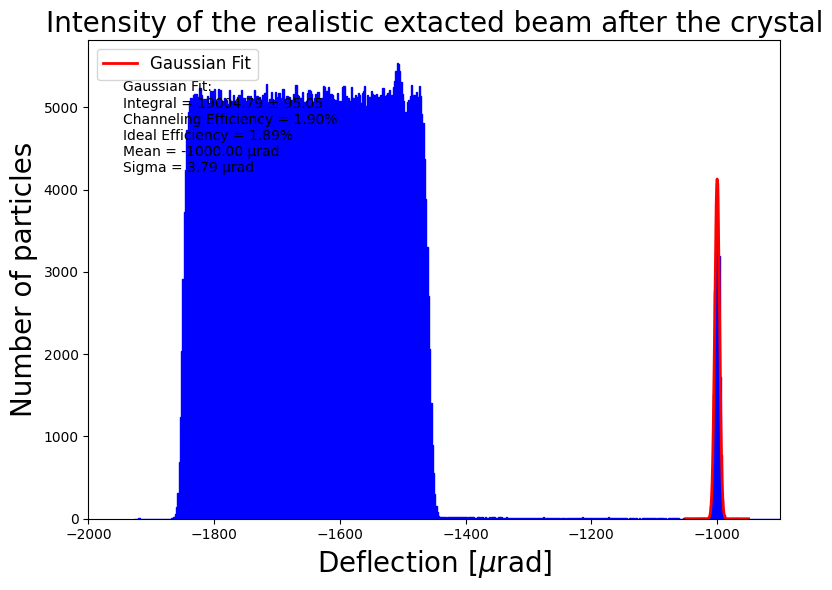

Number of channeled particles (integral of the fit): 19004.79 ± 95.05
Channeling Efficiency: 1.90%
Ideal Efficiency: 1.89%
Fit parameters: Amplitude = 4130.47, Mean = -1000.00, Sigma = 3.79


In [278]:
BendingAngle = coll.bending_angle * 1.e6 #in Microrads
crystal_angle = coll.tilt * 1.e6 #in Microrads
print(BendingAngle)

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))

# Select only surviving particles and only within the window of interest
mask = (part.state > 0) & ((part.px - part_init.px) < BendingAngle * 2) & ((part.px - part_init.px) > -100.e-6)
channeling_px = part.px[mask] * 1.e6  # Convert to µrad

# Generate the histogram data for plotting and fitting
counts, bin_edges = np.histogram(channeling_px, bins=2000, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Restrict fitting to the peak range (130 to 170 µrad)
mask_fit = (bin_centers >= crystal_angle + BendingAngle * 0.9) & (bin_centers <= crystal_angle + BendingAngle * 1.1)
bin_centers_fit = bin_centers[mask_fit]
counts_fit = counts[mask_fit]

# Perform Gaussian fit within the specified range
initial_guess = [np.max(counts_fit), crystal_angle + BendingAngle, 5]
popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit, p0=initial_guess,
                       bounds=([0, BendingAngle*0.9 + crystal_angle, 1], [np.inf,  BendingAngle*1.1 + crystal_angle, 10]))

# Extract fit parameters and errors
amp, mean, sigma = popt
amp_err, mean_err, sigma_err = np.sqrt(np.diag(pcov))

# Plot the histogram and the Gaussian fit only in the fitting range
plt.figure(figsize=(8, 6))
plt.hist(channeling_px, bins=2000, density=False, color='blue', edgecolor='blue')

# Plot the Gaussian fit 
plot_range = np.linspace(crystal_angle + BendingAngle*0.9, crystal_angle + BendingAngle*1.1, 500)
plt.plot(plot_range, gaussian(plot_range, *popt), color='red', linewidth=2, label="Gaussian Fit")

# Calculate the integral (number of channeled particles) and its error
integral = amp * sigma * np.sqrt(2 * np.pi) / bin_width                         #IMPORTANT TO DIVEDE BY BIN_WIDTH
integral_error = integral * np.sqrt((amp_err / amp)**2 + (sigma_err / sigma)**2)

# Calculate efficiency for the main peak relative to total particles in the range
efficiency = integral / num_part * 100
# Ideal efficiency calculated as particles insed range +- 3 sigma of the integral 
lower_bound = mean - 3 * sigma
upper_bound = mean + 3 * sigma
particles_in_range = len(channeling_px[(channeling_px >= lower_bound) & (channeling_px <= upper_bound)])
ideal_efficiency = (particles_in_range / num_part) * 100

# Display fit information on the plot
fit_info = (f"\n"
            f"Gaussian Fit:\n"
            f"Integral = {integral:.2f} ± {integral_error:.2f}\n"
            f"Channeling Efficiency = {efficiency:.2f}%\n"
            f"Ideal Efficiency = {ideal_efficiency:.2f}%\n"
            f"Mean = {mean:.2f} µrad\n"
            f"Sigma = {sigma:.2f} µrad")
plt.text(0.05, 0.95, fit_info, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

# Final plot adjustments
plt.xlabel(r'Deflection [$\mu$rad]', fontsize=20)
plt.xlim(crystal_angle - BendingAngle, crystal_angle + BendingAngle * 1.2)
plt.ylabel('Number of particles', fontsize=20)
plt.title(r'Intensity of the realistic extacted beam after the crystal', fontsize=20)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

# Print the results
print(f"Number of channeled particles (integral of the fit): {integral:.2f} ± {integral_error:.2f}")
print(f"Channeling Efficiency: {efficiency:.2f}%")
print(f"Ideal Efficiency: {ideal_efficiency:.2f}%")
print(f"Fit parameters: Amplitude = {amp:.2f}, Mean = {mean:.2f}, Sigma = {sigma:.2f}")
